# Decision Tree Classifier

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from matplotlib.legend_handler import HandlerLine2D
from sklearn.model_selection import train_test_split

df = pd.read_csv('https://raw.githubusercontent.com/marvv0905/ISOM3360-project/refs/heads/main/datasets/shopping_dataset_dummyCoded.csv')

### Variable set up
- Encode target variable, since cannot use binary to represent due to multi-classed values (Store / Hybrid / Online)
- Splitting features and target variable
- Splitting into training/ test set

In [3]:
#Encoding target variable
encoder = LabelEncoder()

targ = 'shopping_preference'
features = [col for col in df.columns if col != targ]

x = df[features]
y = encoder.fit_transform(df[targ])

#stratify used due to unbalanced dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state = 42)


print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)


{'Hybrid': 0, 'Online': 1, 'Store': 2}
(8252, 28) (3537, 28) (8252,) (3537,)


## Base model

In [4]:
#fit model with train data
base_model = DecisionTreeClassifier()
base_model.fit(x_train, y_train)

dec_tree = base_model.tree_
print(dec_tree.node_count)

fig = plt.figure(figsize=(100,100))
_ = tree.plot_tree(base_model,
                   feature_names = features,
                   class_names= list(encoder.classes_),
                   filled=True)

637


In [5]:
pred_test = base_model.predict(x_test)
print(f'accuracy = {accuracy_score(y_test, pred_test, normalize=True, sample_weight=None)}')
print(classification_report(y_test, pred_test, target_names=encoder.classes_))
print('confusion matrix', '\n', confusion_matrix(y_test, pred_test))

pred_train = base_model.predict(x_train)
print(f'Training data accuracy = {accuracy_score(y_train, pred_train, normalize=True, sample_weight=None)}')


accuracy = 0.926208651399491
              precision    recall  f1-score   support

      Hybrid       0.19      0.24      0.21       111
      Online       0.79      0.77      0.78       353
       Store       0.98      0.97      0.97      3073

    accuracy                           0.93      3537
   macro avg       0.65      0.66      0.66      3537
weighted avg       0.93      0.93      0.93      3537

confusion matrix 
 [[  27   34   50]
 [  57  271   25]
 [  58   37 2978]]
Training data accuracy = 1.0


Out of 111 Hybrid test samples, only 23 were correctly identified. 49 were misclassified as Store and 39 as Online. There is a problem stemming from class imbalance.

Moreover, the model has memorised the training data and generalised poorly due to overfitting. A limit should be set on tree depth.

## Tuning the base model

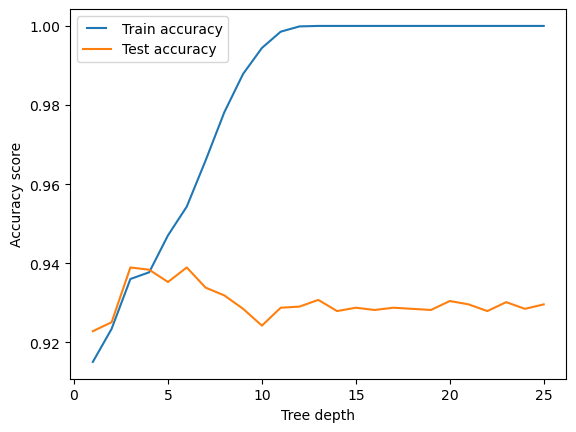

In [6]:
max_depth = np.linspace(1, 25, 25, dtype=int)

train_resultT = []
test_resultT = []

for m in max_depth:
    dtree = DecisionTreeClassifier(max_depth=m)
    dtree.fit(x_train, y_train)

    train_pred = dtree.predict(x_train)
    accuracy = accuracy_score(y_train, train_pred, normalize=True, sample_weight=None)
    train_resultT.append(accuracy)

    test_pred = dtree.predict(x_test)
    accuracy1 = accuracy_score(y_test, test_pred, normalize=True, sample_weight=None)
    test_resultT.append(accuracy1)

line1, = plt.plot(max_depth, train_resultT, label='Train accuracy')
line2, = plt.plot(max_depth, test_resultT, label='Test accuracy')
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('Accuracy score')
plt.xlabel('Tree depth')
plt.show()

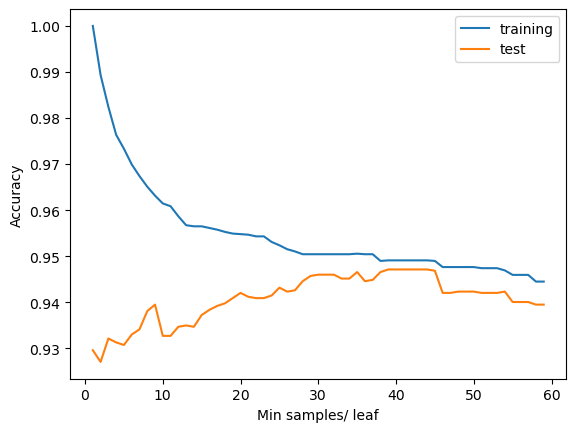

In [7]:
min_leaves = range(1,60)

train_resultL = []
test_resultL = []

for n in min_leaves:
    dtreeL = DecisionTreeClassifier(min_samples_leaf=n, random_state=4)
    dtreeL.fit(x_train, y_train)

    train_predL = dtreeL.predict(x_train)
    accuracyL = accuracy_score(y_train, train_predL, normalize=True, sample_weight=None)
    train_resultL.append(accuracyL)

    test_predL = dtreeL.predict(x_test)
    accuracyL1 = accuracy_score(y_test, test_predL, normalize=True, sample_weight=None)
    test_resultL.append(accuracyL1)

results = pd.DataFrame({"min_leaves": min_leaves, "training": train_resultL, "test":test_resultL})
results.plot("min_leaves")
plt.ylabel("Accuracy")
plt.xlabel("Min samples/ leaf")
plt.show()

### Using gridsearchCV for best parameters

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': range(1, 50, 1),'min_samples_leaf': range(1, 60, 5)}
dtree3 = DecisionTreeClassifier(random_state=42, class_weight = 'balanced')

grid_search = GridSearchCV(estimator = dtree3, param_grid = param_grid, cv = 5, scoring = 'f1_macro')
grid_search.fit(x_train, y_train)

print("Best Hyperparameters found", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Hyperparameters found {'max_depth': 13, 'min_samples_leaf': 1}
Best Cross-Validation Accuracy: 0.6534981578113768


        it seems that an optimal hyperparameter would be max depth = 13, and min samples/ leaf = 1

### Applying it to the model:

In [17]:
final_model = DecisionTreeClassifier(criterion="entropy",max_depth=13, min_samples_leaf=1, class_weight='balanced')
final_model.fit(x_train, y_train)

pred_test3 = final_model.predict(x_test)
print(f'Test data accuracy = {accuracy_score(y_test, pred_test3, normalize=True, sample_weight=None)}')
print('classification report:', '\n',classification_report(y_test,pred_test3,target_names=encoder.classes_))
print('confusion matrix', '\n', confusion_matrix(y_test, pred_test3))

pred_train3 = final_model.predict(x_train)
print(f'Training data accuracy = {accuracy_score(y_train, pred_train3, normalize=True, sample_weight=None)}')


Test data accuracy = 0.927622278767317
classification report: 
               precision    recall  f1-score   support

      Hybrid       0.24      0.32      0.27       111
      Online       0.81      0.78      0.79       353
       Store       0.97      0.97      0.97      3073

    accuracy                           0.93      3537
   macro avg       0.67      0.69      0.68      3537
weighted avg       0.93      0.93      0.93      3537

confusion matrix 
 [[  35   37   39]
 [  38  275   40]
 [  74   28 2971]]
Training data accuracy = 0.98691226369365


## Evaluation

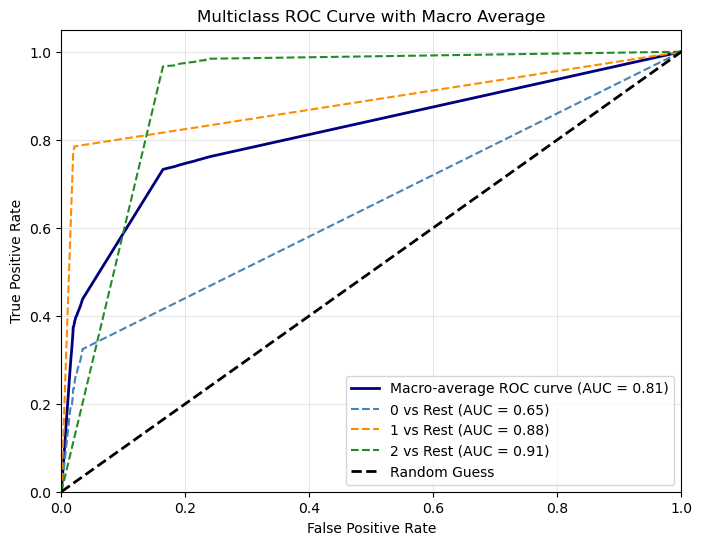

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Assuming final_model, x_test, y_test are already defined
y_score = final_model.predict_proba(x_test)
classes = list(final_model.classes_)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

fpr = dict()
tpr = dict()
roc_auc = dict()

# 1. Calculate individual OvR ROC curves
for i in range(n_classes):    
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 2. Calculate Macro-Average ROC curve
# Aggregate all unique false positive rates across all classes
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Average the interpolated true positive rates and compute AUC
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# 3. Plotting
plt.figure(figsize=(8, 6))

# Plot the Macro-average curve prominently
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC curve (AUC = {roc_auc["macro"]:.2f})',
         color='navy', linestyle='-', linewidth=2)

# Plot individual class curves
colors = ['steelblue', 'darkorange', 'forestgreen']
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color, linestyle='--',
             label=f'{classes[i]} vs Rest (AUC = {roc_auc[i]:.2f})')

# Plot random guess baseline
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Multiclass ROC Curve with Macro Average')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


### Takeaway:

While the Decision Tree model demonstrated strong discriminative ability for the Online and Store classes (AUC = 0.887 and 0.908 respectively), it performed notably poorly in identifying Hybrid shoppers, yielding an AUC of 0.646, only marginally better than a random classifier. 

This can be attributed to the inherently ambiguous nature of the Hybrid class, whose behavioural profile overlaps significantly with both Online and Store shoppers across features. 